In [ ]:
from copy import deepcopy
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import MinMaxScaler

sys.path.append("../")
from src.plots.maps import russia_plots
from src.static.hydro_atlas_analysis import (
    get_cluster_colors,
    get_cluster_markers,
    get_marker_size_corrections,
)
from src.utils.logger import setup_logger

logger = setup_logger("hydrological_analysis", logger_name="../logs/hydrological_analysis.log")

In [99]:
proper_dis = list({i.stem for i in Path("../data/HydroFiles/Discharge").rglob("decent/*.csv")})
proper_lvl = list(
    {i.stem for i in Path("../data/HydroFiles/Levels").rglob("*decent/*.csv") if "shifted" not in str(i)}
)


ws = gpd.read_file("../data/Geometry/WatershedGeomCAMELS.gpkg")
ws.set_index("gauge_id", inplace=True)
ws = ws.loc[[ind for ind in ws.index if (ind in proper_dis)], :]
ws = ws.loc[ws["area"] < 50000, :]
gauge = gpd.read_file("../data/Geometry/GaugeGeomCAMELS.gpkg")
gauge.set_index("gauge_id", inplace=True)
# gauge = gauge.loc[[ind for ind in gauge.index if (ind in proper_dis)], :]
gauge = gauge.loc[ws.index, :]
basemap_data = gpd.read_file("../data/Geometry/basemap.gpkg")


In [183]:
q_df = {}


for gauge_id in ws.index:
    try:
        partial_path = Path(f"../data/HydroFiles/Discharge/partial/decent/{gauge_id}.csv")
        full_path = Path(f"../data/HydroFiles/Discharge/full/decent/{gauge_id}.csv")
        if partial_path.exists():
            df = pd.read_csv(partial_path, parse_dates=True, index_col="date")
        elif full_path.exists():
            df = pd.read_csv(full_path, parse_dates=True, index_col="date")
        else:
            logger.error(gauge_id, None, "missing file")
        if "q_mm_day" not in df.columns or df["q_mm_day"].dropna().empty:
            logger.error(gauge_id, None, "no discharge data")
        q_df[gauge_id] = df[["q_mm_day"]].groupby([df.index.month, df.index.day]).median().values.ravel()
    except Exception as e:
        logger.error(gauge_id, e, "error processing file")
        continue

q_df = pd.DataFrame.from_dict(q_df, orient="columns")
q_df = q_df.loc[:, q_df.max() < 90]
q_df = q_df.dropna(axis=1)
q_df_clust = deepcopy(q_df).T
min_max_scaler = MinMaxScaler()
q_df_clust.loc[:, :] = min_max_scaler.fit_transform(q_df_clust.values)
#  Add gauge lat lon
for gauge_id in q_df_clust.index:
    for i in range(1):
        q_df_clust.loc[gauge_id, f"lat_{i}"] = gauge.loc[gauge_id, "geometry"].x
        q_df_clust.loc[gauge_id, f"lon_{i}"] = gauge.loc[gauge_id, "geometry"].y

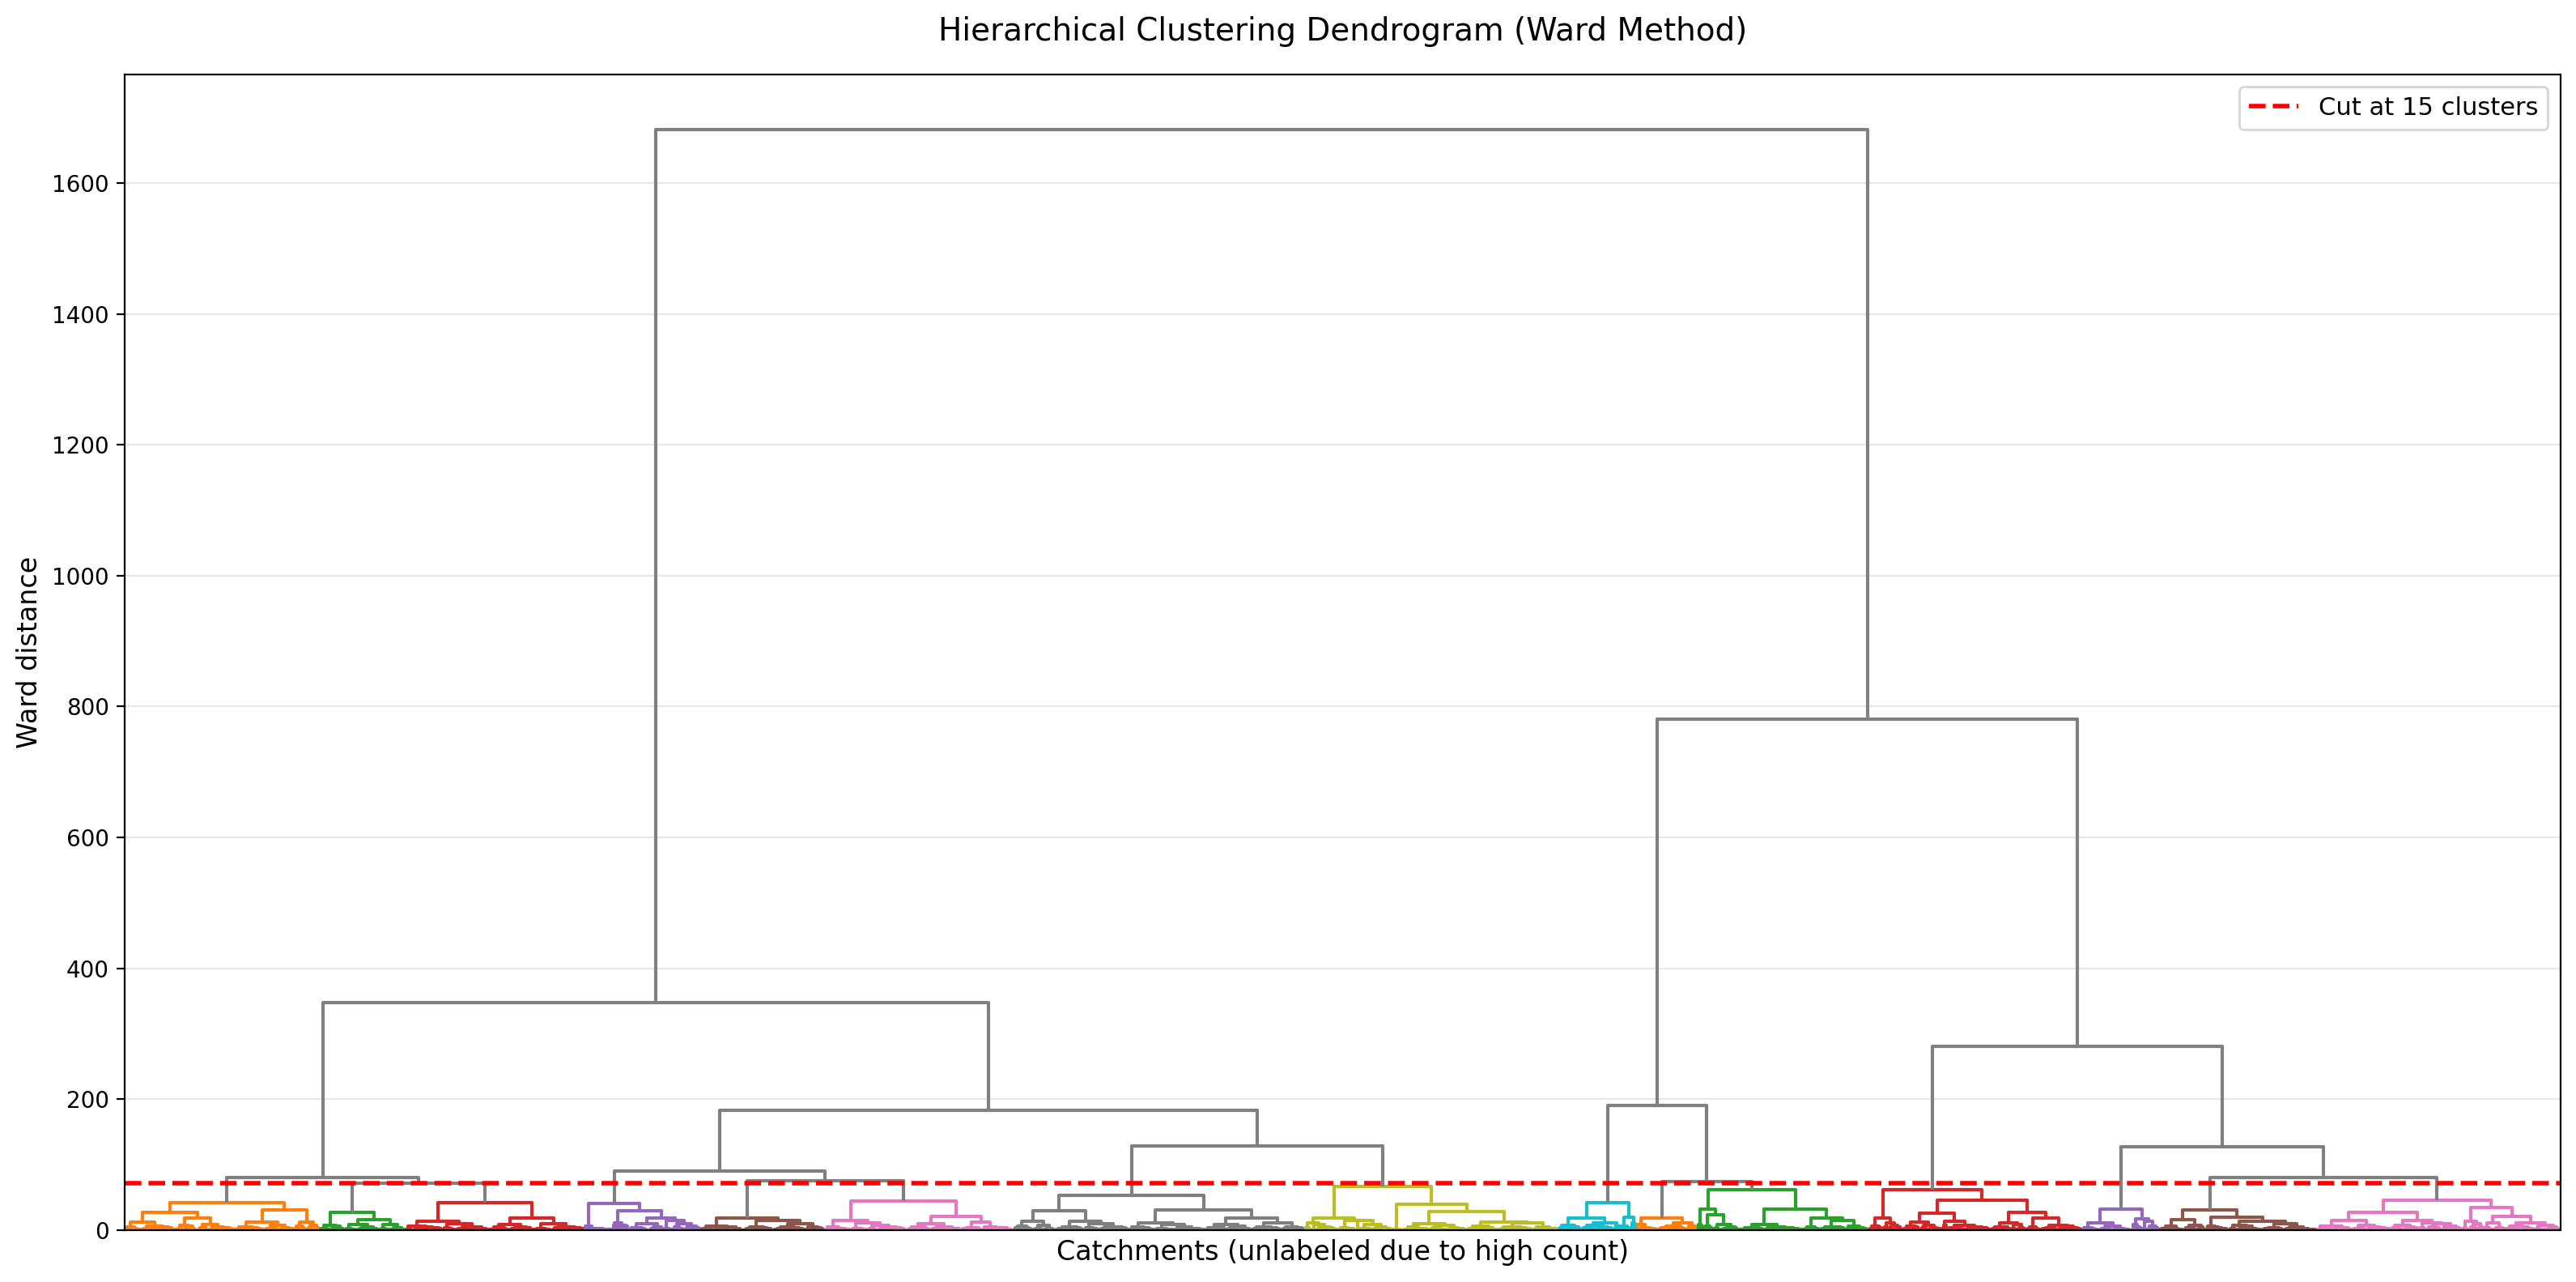

In [ ]:
cluster_number = 15
# Compute linkage matrix
Z = linkage(q_df_clust.values, method="ward", metric="euclidean")

# Plot dendrogram (without x-axis labels due to many gauges)
fig, ax = plt.subplots(figsize=(16, 8))
dendro = dendrogram(
    Z,
    ax=ax,
    above_threshold_color="#808080",
    color_threshold=Z[-cluster_number + 1, 2],
    no_labels=True,  # Don't show gauge IDs on x-axis
    truncate_mode="level",
    p=0,
)

ax.set_xlabel("Catchments (unlabeled due to high count)", fontsize=12)
ax.set_ylabel("Ward distance", fontsize=12)
ax.set_title("Hierarchical Clustering Dendrogram (Ward Method)", fontsize=14, pad=15)
ax.axhline(
    y=Z[-cluster_number + 1, 2], color="r", linestyle="--", linewidth=2, label="Cut at 15 clusters"
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

fig.savefig("../paper/images/dendrogram_ward_14Hydroclusters.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


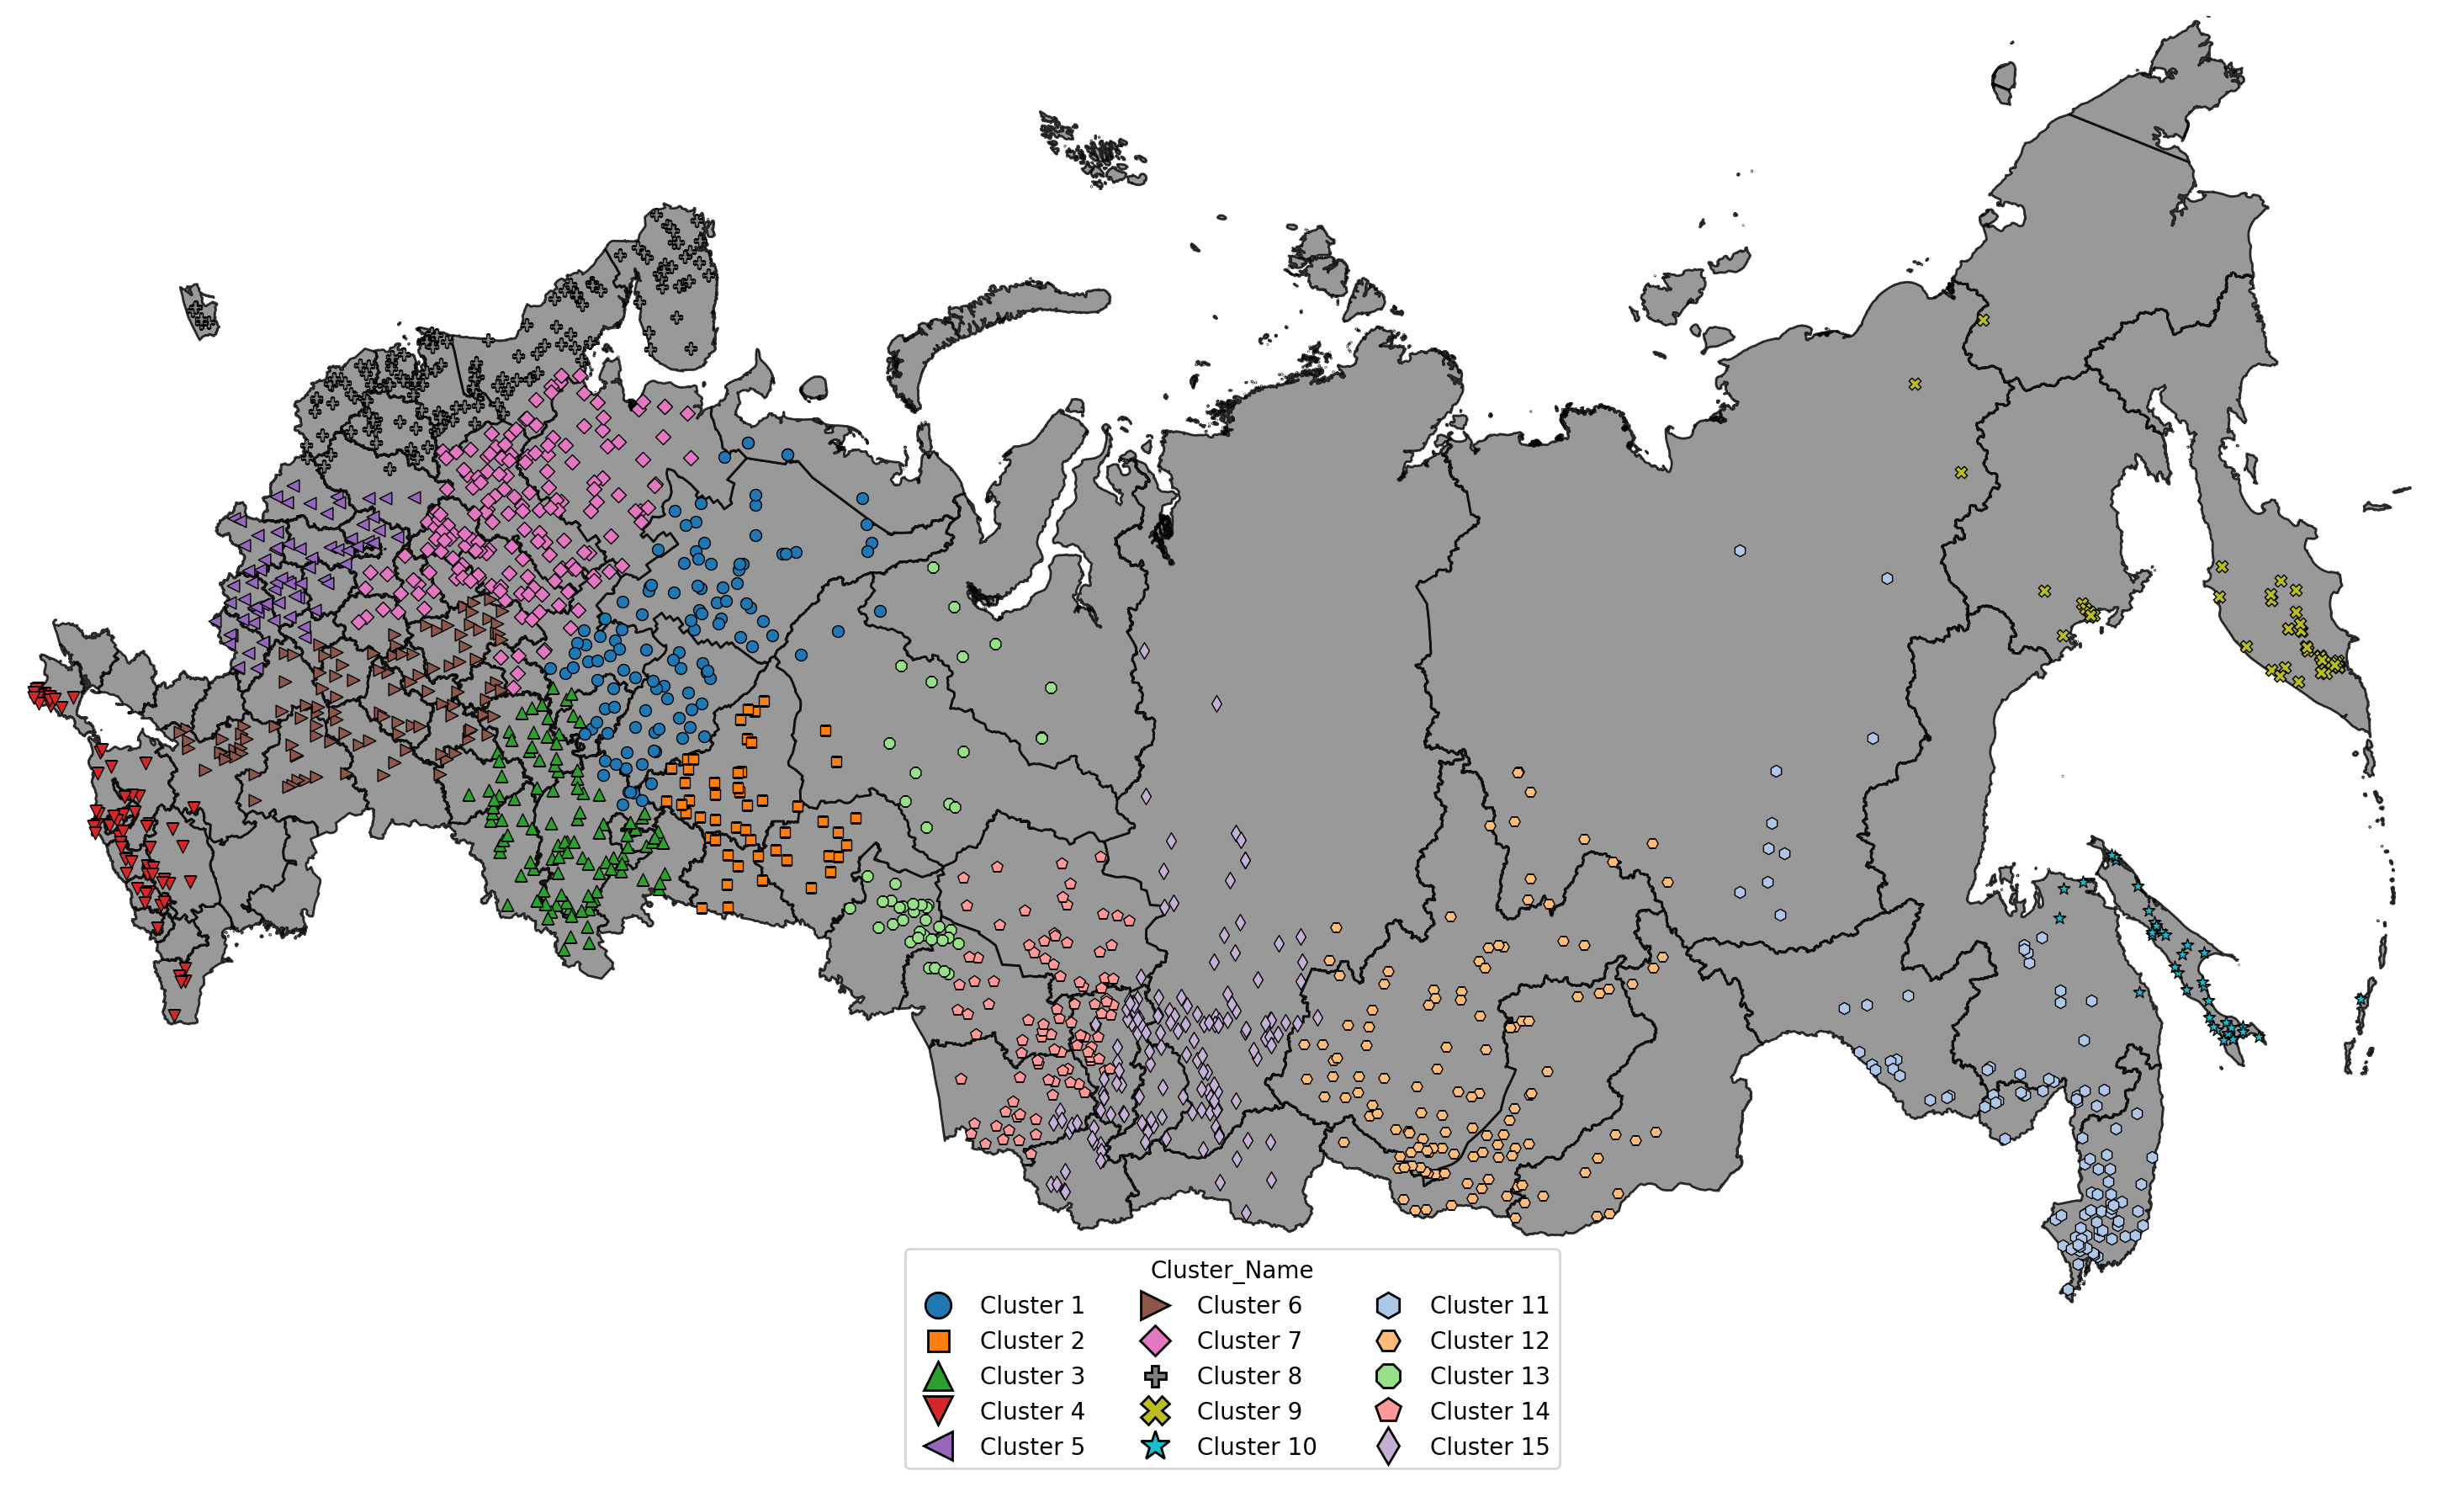

In [199]:
# Extract cluster labels (1-based indexing)
from scipy.cluster.hierarchy import fcluster

hierarchical_labels = fcluster(Z, t=cluster_number, criterion="maxclust")

# Prepare cluster names
gauge_clustered = gauge.loc[q_df.columns, :].copy()
gauge_clustered["Cluster_Name"] = [f"Cluster {cl}" for cl in hierarchical_labels]

# Get markers and colors for 14 clusters
markers_hc = get_cluster_markers(cluster_number)
colors_hc = get_cluster_colors(cluster_number)
marker_corrections = get_marker_size_corrections()

# Plot map
fig_clusters_map = russia_plots(
    gdf_to_plot=gauge_clustered,
    basemap_data=basemap_data,
    distinction_col="Cluster_Name",
    markers_list=markers_hc,
    color_list=colors_hc,
    marker_size_corrections=marker_corrections,
    figsize=(16, 9),
    just_points=True,
    legend_cols=3,
    base_marker_size=25,
    base_linewidth=0.5,
)

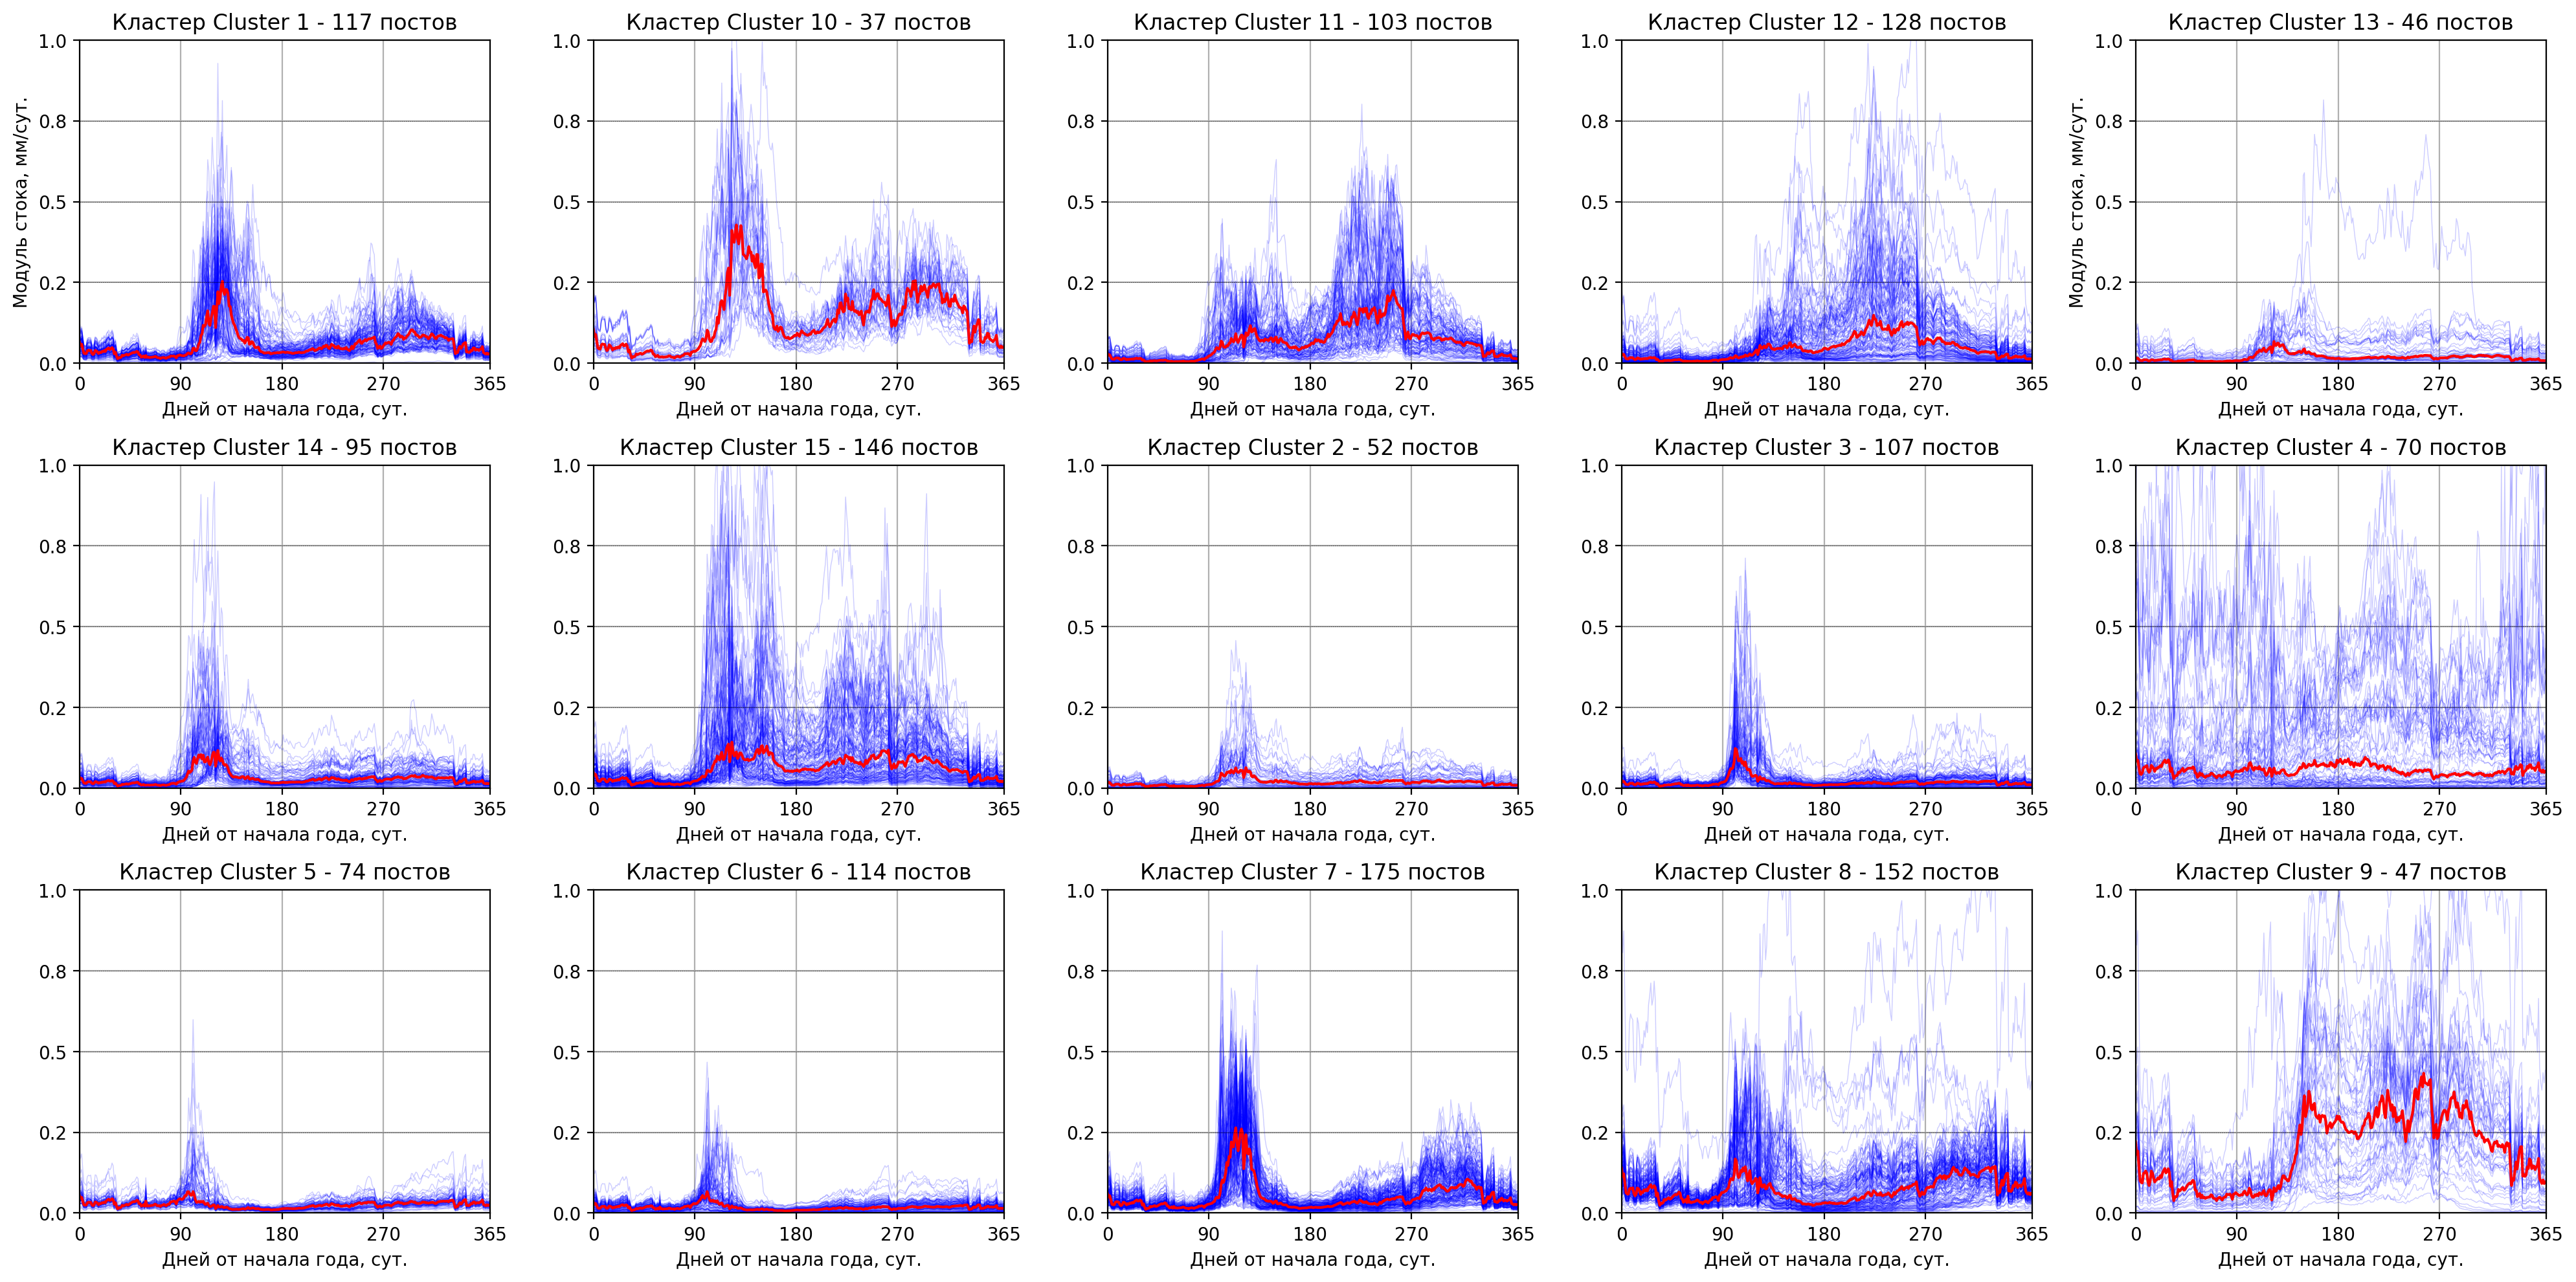

In [205]:
cluster_q_mm = {}
for clust_id, group_id in gauge_clustered.groupby("Cluster_Name").groups.items():
    cluster_q_mm[clust_id] = []
    cluster_q_mm[clust_id] = q_df_clust.loc[group_id, range(366)].T
    cluster_q_mm[clust_id].index = pd.date_range(start="01/01/2000", end="12/31/2000")

q_fig, ax = plt.subplots(nrows=3, ncols=5, figsize=(20, 10))

for i, (clust_ax, (clust_id, clust_data)) in enumerate(
    zip(ax.flatten(), cluster_q_mm.items(), strict=False)
):
    clust_avg = (
        clust_data.groupby([clust_data.index.month, clust_data.index.day])
        .mean()
        .reset_index(drop=True)
        .median(axis=1)
        .values.ravel()
    )

    mean_by_gauge = (
        clust_data.groupby([clust_data.index.month, clust_data.index.day])
        .median()
        .reset_index(drop=True)
    )

    # Define a consistent color and transparency level
    line_color = "blue"  # Example color
    line_alpha = 0.2  # Transparency level (0.0 to 1.0)

    for gauge_id in mean_by_gauge.columns:
        clust_ax.plot(
            mean_by_gauge.index.values,
            mean_by_gauge[f"{gauge_id}"].values,
            color=line_color,
            alpha=line_alpha,
            linewidth=0.5,
        )
    clust_ax.plot(mean_by_gauge.index.values, clust_avg, color="red", alpha=1.0)
    # Hide grid lines
    clust_ax.grid(axis="both", which="both")
    clust_ax.set_xlim(left=0, right=365)

    clust_ax.set_ylim(bottom=0, top=1)
    clust_ax.set_yticks(np.arange(0, 1.25, 0.25))
    clust_ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    if i in [0, 4]:
        clust_ax.set_ylabel("Модуль стока, мм/сут.")
    # if i in [5, 6, 7, 8]:
    clust_ax.set_xlabel("Дней от начала года, сут.")

    for val in np.arange(0, 1.25, 0.25):
        clust_ax.axhline(val, c="black", linestyle="--", linewidth=0.2)
    clust_ax.set_title(f"Кластер {clust_id} - {len(clust_data.columns)} постов")
    clust_ax.set_xticks([0, 90, 180, 270, 365])
q_fig.tight_layout()


# Comprehensive Hydrological Analysis for CAMELS-RU Dataset

This notebook demonstrates the usage of the reorganized hydrological statistics package for comprehensive analysis of multiple gauge stations. The new modular approach allows for efficient calculation of standardized hydrological indices across the entire CAMELS-RU dataset.

## Features:
- **Batch processing** of multiple gauge stations
- **Comprehensive metrics** from all hydrological modules
- **Standardized output** as DataFrame with gauge_id as index
- **Performance optimized** calculations
- **Error handling** for incomplete or problematic data

## Modules Used:
- `src.hydro.base_flow` - Base flow separation and BFI calculation
- `src.hydro.flow_duration` - Flow Duration Curve analysis
- `src.hydro.flow_extremes` - High/low flow analysis
- `src.hydro.flow_timing` - Temporal flow characteristics
- `src.hydro.flow_variability` - Multi-scale variability analysis
- `src.hydro.flow_indices` - Comprehensive hydrological indices

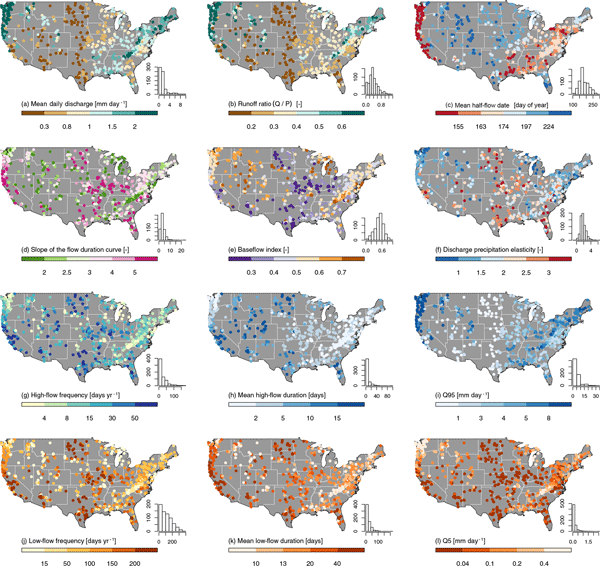

In [ ]:
# mean daily discharge, runoff ratio, mean half-flow ratio, slope of the flow duration curve
# baseflow index, discharge precipitation elsaticity, high-flow frequency, mean high-flow duration
# q95, low-flow frequency, mean low-flow duration, q5

In [22]:
import xarray as xr

with xr.open_dataset(
    "/home/dmbrmv/Development/camels_ru/data/MeteoData/ProcessedGauges/mswep/res/41005.nc"
) as f:
    pass

f

<xarray.Dataset> Size: 234kB
Dimensions:      (date: 5844)
Coordinates:
  * date         (date) datetime64[ns] 47kB 2007-01-01 2007-01-02 ... 2022-12-31
Data variables:
    prcp         (date) float32 23kB ...
    gauge_id     (date) <U5 117kB ...
    day_of_year  (date) float64 47kB ...

In [15]:
# Setup and imports

from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Import the new modular hydro package

sys.path.append("../")

from src.hydro import (
    FlowDurationCurve,
    FlowExtremes,
    FlowTiming,
    FlowVariability,
    calculate_comprehensive_metrics,
)

In [5]:
# Load discharge data
print("Loading discharge data...")
discharge_data = pd.read_csv("../discharge.csv", index_col="date")
discharge_data.index = pd.to_datetime(discharge_data.index)

# Remove columns with too many NaN values (less than 2 years of data)
min_data_points = 730  # Minimum 2 years of daily data
discharge_data = discharge_data.dropna(axis=1, thresh=min_data_points)

print(f"Loaded data for {len(discharge_data.columns)} gauge stations")
print(f"Date range: {discharge_data.index.min()} to {discharge_data.index.max()}")
print(f"Total data points per station (max): {len(discharge_data)}")

# Display basic info about the dataset
discharge_data.info()

Loading discharge data...
Loaded data for 1983 gauge stations
Date range: 2008-01-01 00:00:00 to 2020-12-31 00:00:00
Total data points per station (max): 4749
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4749 entries, 2008-01-01 to 2020-12-31
Columns: 1983 entries, 3120 to 10075
dtypes: float64(1983)
memory usage: 71.9 MB


## Core Function: Batch Hydrological Analysis

The following function processes multiple gauge stations efficiently and returns a standardized DataFrame with comprehensive hydrological statistics.

In [6]:
def calculate_hydrological_statistics_batch(
    discharge_data: pd.DataFrame,
    gauge_ids: list[str] | None = None,
    min_data_years: float = 2.0,
    include_bfi: bool = True,
    include_detailed_metrics: bool = True,
    progress_bar: bool = True,
) -> pd.DataFrame:
    """
    Calculate comprehensive hydrological statistics for multiple gauge stations.

    Parameters:
    -----------
    discharge_data : pd.DataFrame
        DataFrame with datetime index and gauge IDs as columns
    gauge_ids : List[str], optional
        List of specific gauge IDs to process. If None, processes all columns
    min_data_years : float
        Minimum years of data required for analysis (default: 2.0)
    include_bfi : bool
        Whether to calculate BFI (computationally intensive, default: True)
    include_detailed_metrics : bool
        Whether to include all detailed metrics from all modules (default: True)
    progress_bar : bool
        Whether to show progress bar (default: True)

    Returns:
    --------
    pd.DataFrame
        DataFrame with gauge_id as index and calculated statistics as columns
    """

    # Select gauge IDs to process
    if gauge_ids is None:
        gauge_ids = discharge_data.columns.tolist()

    # Filter gauge IDs that actually exist in the data
    available_gauges = [gid for gid in gauge_ids if gid in discharge_data.columns]

    print(f"Processing {len(available_gauges)} gauge stations...")

    # Initialize results storage
    results = {}
    failed_gauges = []

    # Setup progress bar
    iterator = tqdm(available_gauges) if progress_bar else available_gauges

    for gauge_id in iterator:
        try:
            if progress_bar:
                iterator.set_description(f"Processing {gauge_id}")

            # Extract discharge series for this gauge
            discharge_series = discharge_data[gauge_id].dropna()

            # Check minimum data requirement
            years_of_data = len(discharge_series) / 365.25
            if years_of_data < min_data_years:
                if progress_bar:
                    iterator.set_postfix({"status": f"skipped - {years_of_data:.1f}y"})
                continue

            # Calculate comprehensive metrics
            metrics = calculate_comprehensive_metrics(
                discharge_series, include_bfi=include_bfi, include_all_modules=include_detailed_metrics
            )

            # Add basic data quality metrics
            metrics.update(
                {
                    "data_years": years_of_data,
                    "data_points": len(discharge_series),
                    "data_completeness": len(discharge_series) / len(discharge_data) * 100,
                    "start_date": discharge_series.index.min(),
                    "end_date": discharge_series.index.max(),
                }
            )

            results[gauge_id] = metrics

            if progress_bar:
                iterator.set_postfix({"status": f"completed - {len(metrics)} metrics"})

        except Exception as e:
            failed_gauges.append((gauge_id, str(e)))
            if progress_bar:
                iterator.set_postfix({"status": f"failed - {str(e)[:20]}..."})
            continue

    # Convert results to DataFrame
    if results:
        results_df = pd.DataFrame.from_dict(results, orient="index")
        results_df.index.name = "gauge_id"

        print(f"\nSuccessfully processed {len(results_df)} gauge stations")
        print(f"Failed to process {len(failed_gauges)} gauge stations")

        if failed_gauges:
            print("Failed gauges:")
            for gauge_id, error in failed_gauges[:5]:  # Show first 5 failures
                print(f"  {gauge_id}: {error}")
            if len(failed_gauges) > 5:
                print(f"  ... and {len(failed_gauges) - 5} more")

        return results_df
    else:
        print("No gauge stations were successfully processed!")
        return pd.DataFrame()

## Use Case 1: Quick Analysis for All Stations

Process all available gauge stations with a subset of key metrics for rapid assessment.

In [7]:
# Quick analysis for first 10 stations (for demonstration)
sample_stations = discharge_data.columns[:10].tolist()

print("=== USE CASE 1: Quick Analysis (Key Metrics Only) ===")
start_time = time.time()

# Quick analysis without BFI and detailed metrics for speed
quick_results = calculate_hydrological_statistics_batch(
    discharge_data,
    gauge_ids=sample_stations,
    min_data_years=1.0,
    include_bfi=False,  # Skip BFI for speed
    include_detailed_metrics=False,  # Only basic metrics
    progress_bar=True,
)

elapsed_time = time.time() - start_time
print(f"\nQuick analysis completed in {elapsed_time:.2f} seconds")
print(f"Generated {len(quick_results.columns)} metrics per station")

# Display first few results
print("\nSample results (first 5 stations, selected metrics):")
key_metrics = [
    col
    for col in quick_results.columns
    if any(x in col.lower() for x in ["mean", "cv", "q05", "q95", "fdc_slope", "data_years"])
]
print(quick_results[key_metrics].head())

=== USE CASE 1: Quick Analysis (Key Metrics Only) ===
Processing 10 gauge stations...


  0%|          | 0/10 [00:00<?, ?it/s]


Successfully processed 10 gauge stations
Failed to process 0 gauge stations

Quick analysis completed in 0.07 seconds
Generated 36 metrics per station

Sample results (first 5 stations, selected metrics):
          data_years
gauge_id            
3120        7.917864
75758      12.999316
2090       13.002053
2103       13.002053
84037      12.999316


## Use Case 2: Comprehensive Analysis for Selected Stations

Perform detailed analysis including BFI calculation and all available metrics for a subset of high-quality stations.

In [9]:
# Select high-quality stations (those with >5 years of data)
print("=== USE CASE 2: Comprehensive Analysis for High-Quality Stations ===")

# Find stations with sufficient data
data_coverage = discharge_data.count() / len(discharge_data) * 100
long_record_stations = data_coverage[data_coverage > 80].index[:5].tolist()  # Top 5 stations

print(f"Selected {len(long_record_stations)} high-quality stations for detailed analysis:")
for station in long_record_stations:
    coverage = data_coverage[station]
    print(f"  {station}: {coverage:.1f}% data coverage")

start_time = time.time()

# Comprehensive analysis with all metrics including BFI
comprehensive_results = calculate_hydrological_statistics_batch(
    discharge_data,
    gauge_ids=long_record_stations,
    min_data_years=3.0,
    include_bfi=True,  # Include BFI calculation
    include_detailed_metrics=True,  # All available metrics
    progress_bar=True,
)

elapsed_time = time.time() - start_time
print(f"\nComprehensive analysis completed in {elapsed_time:.2f} seconds")
print(f"Generated {len(comprehensive_results.columns)} metrics per station")

# Display comprehensive results
print("\nComprehensive results overview:")
print(f"Shape: {comprehensive_results.shape}")
print("Metrics categories:")

# Group metrics by category
metric_categories = {}
for col in comprehensive_results.columns:
    category = col.split("_")[0] if "_" in col else "basic"
    if category not in metric_categories:
        metric_categories[category] = []
    metric_categories[category].append(col)

for category, metrics in metric_categories.items():
    print(f"  {category}: {len(metrics)} metrics")

comprehensive_results.head()

=== USE CASE 2: Comprehensive Analysis for High-Quality Stations ===
Selected 5 high-quality stations for detailed analysis:
  75758: 100.0% data coverage
  2090: 100.0% data coverage
  2103: 100.0% data coverage
  84037: 100.0% data coverage
  4036: 100.0% data coverage
Processing 5 gauge stations...


  0%|          | 0/5 [00:00<?, ?it/s]


Successfully processed 5 gauge stations
Failed to process 0 gauge stations

Comprehensive analysis completed in 0.32 seconds
Generated 154 metrics per station

Comprehensive results overview:
Shape: (5, 154)
Metrics categories:
  magnitude: 16 metrics
  frequency: 4 metrics
  duration: 4 metrics
  timing: 30 metrics
  rate: 5 metrics
  fdc: 20 metrics
  extreme: 33 metrics
  variability: 36 metrics
  baseflow: 1 metrics
  data: 3 metrics
  start: 1 metrics
  end: 1 metrics


,magnitude_ma01,magnitude_ma02,magnitude_ma15,magnitude_ma16,magnitude_ma03,magnitude_ma04,magnitude_ma05,magnitude_ma06,magnitude_ma07,magnitude_ma08,...,variability_max_annual_ratio,variability_annual_max_cv,variability_annual_min_cv,variability_annual_mean_trend,baseflow_bfi,data_years,data_points,data_completeness,start_date,end_date
gauge_id,,,,,,,,,,,,,,,,,,,,,
75758,1.371837,0.46,3.590000,2.616930,0.658486,0.469918,2.214739,7.083564,1.046625,0.644077,...,2.910088,0.480509,0.394456,-0.043450,0.385502,12.999316,4748,99.978943,2008-01-01,2020-12-31
2090,138.415414,103.00,98.844184,0.714113,74.015136,73.467120,73.094541,81.506154,157.237469,351.528205,...,1.649532,0.388670,0.128448,1.793226,0.763006,13.002053,4749,100.000000,2008-01-01,2020-12-31
2103,6.830619,5.72,3.280460,0.480258,4.267196,4.545245,4.786725,4.979744,6.070620,11.456308,...,1.379256,0.406795,0.215493,0.018950,0.830018,13.002053,4749,100.000000,2008-01-01,2020-12-31
84037,15.906152,12.20,13.161269,0.827433,10.892432,11.903043,16.883557,20.512385,23.426948,32.011051,...,3.859162,0.587507,0.478302,-0.421371,0.708823,12.999316,4748,99.978943,2008-01-01,2020-12-31
4036,1.762374,0.69,2.969416,1.684895,0.311390,0.236367,0.254052,1.635615,9.009603,2.353436,...,1.764262,0.263764,0.471459,0.017930,0.453898,13.002053,4749,100.000000,2008-01-01,2020-12-31


## Use Case 3: Custom Metrics for Specific Analysis

Calculate specific sets of metrics for targeted research questions (e.g., drought analysis, flood analysis, baseflow studies).

In [16]:
def calculate_drought_focused_metrics(
    discharge_data: pd.DataFrame, gauge_ids: list[str]
) -> pd.DataFrame:
    """Calculate metrics specifically focused on drought analysis."""

    results = {}

    for gauge_id in tqdm(gauge_ids, desc="Drought analysis"):
        discharge_series = discharge_data[gauge_id].dropna()

        if len(discharge_series) < 730:  # Skip if less than 2 years
            continue

        # Initialize analyzers
        extremes = FlowExtremes(discharge_series)
        variability = FlowVariability(discharge_series)
        fdc = FlowDurationCurve(discharge_series)

        # Drought-specific metrics
        drought_metrics = extremes.calculate_drought_indices()
        low_flow_metrics = extremes.analyze_low_flows(threshold_multiplier=0.1)  # Stricter threshold

        # Additional drought indicators
        q70 = fdc.get_percentile_flow(70)
        q80 = fdc.get_percentile_flow(80)
        q90 = fdc.get_percentile_flow(90)
        q95 = fdc.get_percentile_flow(95)

        # Combine drought-focused metrics
        metrics = {
            "gauge_id": gauge_id,
            "q70": q70,
            "q80": q80,
            "q90": q90,
            "q95": q95,
            "q95_mean_ratio": drought_metrics["q95_flow"] / np.mean(discharge_series),
            "low_flow_frequency": low_flow_metrics["low_flow_frequency"],
            "low_flow_duration_avg": low_flow_metrics["low_flow_avg_duration"],
            "low_flow_duration_max": low_flow_metrics["low_flow_max_duration"],
            "baseflow_approx": drought_metrics["bfi_approx"],
            "cv": np.std(discharge_series) / np.mean(discharge_series),
            "data_years": len(discharge_series) / 365.25,
        }

        results[gauge_id] = metrics

    return pd.DataFrame.from_dict(results, orient="index")


def calculate_flood_focused_metrics(discharge_data: pd.DataFrame, gauge_ids: list[str]) -> pd.DataFrame:
    """Calculate metrics specifically focused on flood analysis."""

    results = {}

    for gauge_id in tqdm(gauge_ids, desc="Flood analysis"):
        discharge_series = discharge_data[gauge_id].dropna()

        if len(discharge_series) < 730:  # Skip if less than 2 years
            continue

        # Initialize analyzers
        extremes = FlowExtremes(discharge_series)
        variability = FlowVariability(discharge_series)
        fdc = FlowDurationCurve(discharge_series)

        # Flood-specific metrics
        flood_metrics = extremes.calculate_flood_indices()
        high_flow_metrics = extremes.analyze_high_flows(
            threshold_multiplier=3.0
        )  # Conservative threshold
        flashiness = variability.calculate_flashiness_index()

        # Additional flood indicators
        q05 = fdc.get_percentile_flow(5)
        q10 = fdc.get_percentile_flow(10)
        q20 = fdc.get_percentile_flow(20)

        # Combine flood-focused metrics
        metrics = {
            "gauge_id": gauge_id,
            "q05": q05,
            "q10": q10,
            "q20": q20,
            "q05_mean_ratio": q05 / np.mean(discharge_series),
            "high_flow_frequency": high_flow_metrics["high_flow_frequency"],
            "high_flow_duration_avg": high_flow_metrics["high_flow_avg_duration"],
            "high_flow_duration_max": high_flow_metrics["high_flow_max_duration"],
            "flashiness_index": flashiness["flashiness_index"],
            "max_daily_rise": flood_metrics.get("max_daily_rise", np.nan),
            "flood_threshold": flood_metrics["flood_threshold"],
            "data_years": len(discharge_series) / 365.25,
        }

        results[gauge_id] = metrics

    return pd.DataFrame.from_dict(results, orient="index")


# Example: Drought analysis for selected stations
print("=== USE CASE 3A: Drought-Focused Analysis ===")
drought_results = calculate_drought_focused_metrics(discharge_data, sample_stations)
print(f"Drought analysis completed for {len(drought_results)} stations")
print("\nDrought metrics summary:")
drought_results.describe()

=== USE CASE 3A: Drought-Focused Analysis ===


Drought analysis:   0%|          | 0/10 [00:00<?, ?it/s]

Drought analysis completed for 10 stations

Drought metrics summary:


,q70,q80,q90,q95,q95_mean_ratio,low_flow_frequency,low_flow_duration_avg,low_flow_duration_max,baseflow_approx,cv,data_years
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,13.871610,11.931800,9.775900,8.776100,0.201713,6.017602,35.836310,58.600000,0.201713,1.562938,11.324298
std,24.518702,22.743105,20.494763,19.725308,0.188512,9.804251,49.408520,80.224961,0.188512,0.835549,2.818498
min,0.096100,0.030000,0.025000,0.020000,0.015687,0.000000,0.000000,0.000000,0.015687,0.480258,5.497604
25%,1.525000,1.207500,0.523000,0.287500,0.065909,0.000000,0.000000,0.000000,0.065909,0.843368,9.865845
50%,4.970000,4.465000,3.456000,2.340500,0.153259,0.021061,1.500000,1.500000,0.153259,1.588336,12.999316
75%,13.650000,9.011000,5.730000,4.360000,0.260816,7.394529,81.875000,123.000000,0.260816,2.186731,13.002053
max,81.600000,75.500000,67.300000,64.300000,0.576814,27.988048,122.071429,195.000000,0.576814,2.843535,13.002053


In [17]:
# Example: Flood analysis for selected stations
print("=== USE CASE 3B: Flood-Focused Analysis ===")
flood_results = calculate_flood_focused_metrics(discharge_data, sample_stations)
print(f"Flood analysis completed for {len(flood_results)} stations")
print("\nFlood metrics summary:")
flood_results.describe()

=== USE CASE 3B: Flood-Focused Analysis ===


Flood analysis:   0%|          | 0/10 [00:00<?, ?it/s]

Flood analysis completed for 10 stations

Flood metrics summary:


,q05,q10,q20,q05_mean_ratio,high_flow_frequency,high_flow_duration_avg,high_flow_duration_max,flashiness_index,max_daily_rise,flood_threshold,data_years
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,100.86955,65.847300,41.233000,3.343645,13.892101,18.037866,67.300000,0.107040,199.042000,312.818589,11.324298
std,130.55195,89.935648,58.933687,0.930228,7.718028,11.475680,32.768718,0.073300,338.759029,493.425518,2.818498
min,3.02950,1.793000,0.940000,2.058379,2.400505,8.125000,33.000000,0.027101,8.190000,19.739960,5.497604
25%,9.68750,6.175000,3.655000,2.588114,6.601868,10.641577,51.250000,0.048888,18.057500,36.044231,9.865845
50%,33.60000,24.900000,17.630000,3.340912,15.395956,15.995120,61.500000,0.093945,26.200000,86.038462,12.999316
75%,135.43250,69.762500,39.960000,3.819390,21.017108,18.468682,71.000000,0.125089,140.550000,223.670560,13.002053
max,338.60000,253.000000,178.400000,4.739340,22.657402,47.782609,148.000000,0.235488,840.000000,1444.615385,13.002053


## Use Case 4: Flow Regime Classification

Classify flow regimes across all stations using key hydrological signatures and create a comprehensive regime database.

In [18]:
def classify_flow_regimes(discharge_data: pd.DataFrame, gauge_ids: list[str]) -> pd.DataFrame:
    """Classify flow regimes using key hydrological signatures."""

    from src.hydro.flow_indices import calculate_regime_classification_metrics

    results = {}

    for gauge_id in tqdm(gauge_ids, desc="Regime classification"):
        discharge_series = discharge_data[gauge_id].dropna()

        if len(discharge_series) < 1095:  # Require at least 3 years
            continue

        # Calculate classification metrics
        classification_metrics = calculate_regime_classification_metrics(discharge_series)

        # Additional signature metrics
        fdc = FlowDurationCurve(discharge_series)
        variability = FlowVariability(discharge_series)

        # Key signatures for classification
        fdc_slope = fdc.calculate_fdc_slope()
        cv = np.std(discharge_series) / np.mean(discharge_series)
        q5_q95_ratio = fdc.get_percentile_flow(5) / fdc.get_percentile_flow(95)

        # Seasonal signatures
        if isinstance(discharge_series.index, pd.DatetimeIndex):
            timing = FlowTiming(discharge_series)
            seasonal_metrics = timing.calculate_seasonal_flows()

            # Summer vs winter flow ratio
            summer_ratio = seasonal_metrics.get("summer_ratio", np.nan)
            winter_ratio = seasonal_metrics.get("winter_ratio", np.nan)
        else:
            summer_ratio = np.nan
            winter_ratio = np.nan

        # Enhanced regime classification
        regime_type = classification_metrics["regime_classification"]

        # Additional classification based on seasonal patterns
        if not np.isnan(summer_ratio) and not np.isnan(winter_ratio):
            if summer_ratio > 1.5:
                regime_subtype = "snowmelt_dominated"
            elif winter_ratio > 1.5:
                regime_subtype = "rain_dominated"
            else:
                regime_subtype = "mixed"
        else:
            regime_subtype = "unknown"

        metrics = {
            "gauge_id": gauge_id,
            "regime_type": regime_type,
            "regime_subtype": regime_subtype,
            "fdc_slope": fdc_slope,
            "coefficient_of_variation": cv,
            "q5_q95_ratio": q5_q95_ratio,
            "summer_ratio": summer_ratio,
            "winter_ratio": winter_ratio,
            "baseflow_ratio_approx": classification_metrics["baseflow_ratio_approx"],
            "mean_flow": float(np.mean(discharge_series)),
            "data_years": len(discharge_series) / 365.25,
        }

        results[gauge_id] = metrics

    return pd.DataFrame.from_dict(results, orient="index")


print("=== USE CASE 4: Flow Regime Classification ===")
regime_results = classify_flow_regimes(discharge_data, sample_stations)
print(f"Regime classification completed for {len(regime_results)} stations")

# Display classification results
print("\nFlow regime distribution:")
print(regime_results["regime_type"].value_counts())
print("\nRegime subtype distribution:")
print(regime_results["regime_subtype"].value_counts())

print("\nRegime classification summary:")
regime_results.head()

=== USE CASE 4: Flow Regime Classification ===


Regime classification:   0%|          | 0/10 [00:00<?, ?it/s]

Regime classification completed for 10 stations

Flow regime distribution:
regime_type
variable              9
baseflow_dominated    1
Name: count, dtype: int64

Regime subtype distribution:
regime_subtype
mixed                 8
snowmelt_dominated    2
Name: count, dtype: int64

Regime classification summary:


,gauge_id,regime_type,regime_subtype,fdc_slope,coefficient_of_variation,q5_q95_ratio,summer_ratio,winter_ratio,baseflow_ratio_approx,mean_flow,data_years
3120,3120,variable,mixed,3.634667,1.745431,244.928625,1.408019,0.204411,0.015687,84.848813,7.917864
75758,75758,variable,mixed,2.239263,2.616930,25.730000,0.363140,0.520336,0.145790,1.371837,12.999316
2090,2090,variable,snowmelt_dominated,1.478710,0.714113,5.265941,1.778351,0.549860,0.464544,138.415414,13.002053
2103,2103,baseflow_dominated,snowmelt_dominated,0.825453,0.480258,3.568528,1.611494,0.659211,0.576814,6.830619,13.002053
84037,84037,variable,mixed,1.307457,0.827433,9.022222,1.334159,0.680958,0.282909,15.906152,12.999316


## Use Case 5: Production Pipeline for Full Dataset

Production-ready pipeline for processing the entire CAMELS-RU dataset with optimizations for large-scale processing.

In [19]:
def production_pipeline_full_dataset(
    discharge_data: pd.DataFrame,
    output_dir: str = "../results/",
    chunk_size: int = 50,
    save_intermediate: bool = True,
) -> pd.DataFrame:
    """
    Production pipeline for processing the full CAMELS-RU dataset.

    Features:
    - Chunked processing to manage memory
    - Intermediate saves for fault tolerance
    - Multiple output formats
    - Quality control and validation
    """

    # Ensure output directory exists
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Get all available gauge stations
    all_stations = discharge_data.columns.tolist()
    print(f"Total stations to process: {len(all_stations)}")

    # Split into chunks for processing
    chunks = [all_stations[i : i + chunk_size] for i in range(0, len(all_stations), chunk_size)]
    print(f"Processing in {len(chunks)} chunks of {chunk_size} stations each")

    all_results = []

    for i, chunk in enumerate(chunks):
        print(f"\n--- Processing Chunk {i + 1}/{len(chunks)} ---")
        print(f"Stations {i * chunk_size + 1} to {min((i + 1) * chunk_size, len(all_stations))}")

        try:
            # Process chunk with comprehensive metrics
            chunk_results = calculate_hydrological_statistics_batch(
                discharge_data,
                gauge_ids=chunk,
                min_data_years=1.0,
                include_bfi=True,  # Include BFI for production
                include_detailed_metrics=True,
                progress_bar=True,
            )

            if len(chunk_results) > 0:
                all_results.append(chunk_results)

                # Save intermediate results
                if save_intermediate:
                    chunk_file = f"{output_dir}/hydro_metrics_chunk_{i + 1:03d}.csv"
                    chunk_results.to_csv(chunk_file)
                    print(f"Saved intermediate results to {chunk_file}")

        except Exception as e:
            print(f"Error processing chunk {i + 1}: {e}")
            continue

    # Combine all results
    if all_results:
        final_results = pd.concat(all_results, axis=0)

        # Quality control
        print("\n--- Quality Control ---")
        print(f"Total stations processed: {len(final_results)}")
        print(f"Total metrics calculated: {len(final_results.columns)}")

        # Check for stations with insufficient data
        insufficient_data = final_results[final_results["data_years"] < 2.0]
        if len(insufficient_data) > 0:
            print(f"Warning: {len(insufficient_data)} stations have less than 2 years of data")

        # Save final results in multiple formats
        final_results.to_csv(f"{output_dir}/camels_ru_hydrological_metrics_complete.csv")
        final_results.to_parquet(f"{output_dir}/camels_ru_hydrological_metrics_complete.parquet")

        # Save metadata
        metadata = {
            "processing_date": pd.Timestamp.now().isoformat(),
            "total_stations": len(final_results),
            "total_metrics": len(final_results.columns),
            "data_period": f"{discharge_data.index.min()} to {discharge_data.index.max()}",
            "metric_categories": list(
                set([col.split("_")[0] for col in final_results.columns if "_" in col])
            ),
        }

        pd.Series(metadata).to_json(f"{output_dir}/processing_metadata.json", indent=2)

        print(f"\nFinal results saved to {output_dir}")
        return final_results

    else:
        print("No stations were successfully processed!")
        return pd.DataFrame()


# For demonstration, run on a subset (uncomment next lines to run full dataset)
print("=== USE CASE 5: Production Pipeline (Demo with 20 stations) ===")

# Demo with first 20 stations
demo_stations = discharge_data.columns[:20]
demo_data = discharge_data[demo_stations]

production_results = production_pipeline_full_dataset(
    demo_data, output_dir="../results/demo/", chunk_size=10, save_intermediate=True
)

print(f"\nProduction pipeline completed. Final dataset shape: {production_results.shape}")

# Generate summary statistics
print("\n--- Summary Statistics ---")
summary_stats = {
    "mean_data_years": production_results["data_years"].mean(),
    "stations_with_5plus_years": (production_results["data_years"] >= 5).sum(),
    "stations_with_10plus_years": (production_results["data_years"] >= 10).sum(),
    "mean_cv": production_results["magnitude_ma16"].mean()
    if "magnitude_ma16" in production_results.columns
    else np.nan,
    "stations_processed": len(production_results),
}

for key, value in summary_stats.items():
    print(f"{key}: {value}")

# Display first few rows of final results
production_results.head()

=== USE CASE 5: Production Pipeline (Demo with 20 stations) ===
Total stations to process: 20
Processing in 2 chunks of 10 stations each

--- Processing Chunk 1/2 ---
Stations 1 to 10
Processing 10 gauge stations...


  0%|          | 0/10 [00:00<?, ?it/s]


Successfully processed 10 gauge stations
Failed to process 0 gauge stations
Saved intermediate results to ../results/demo//hydro_metrics_chunk_001.csv

--- Processing Chunk 2/2 ---
Stations 11 to 20
Processing 10 gauge stations...


  0%|          | 0/10 [00:00<?, ?it/s]


Successfully processed 10 gauge stations
Failed to process 0 gauge stations
Saved intermediate results to ../results/demo//hydro_metrics_chunk_002.csv

--- Quality Control ---
Total stations processed: 20
Total metrics calculated: 154

Final results saved to ../results/demo/

Production pipeline completed. Final dataset shape: (20, 154)

--- Summary Statistics ---
mean_data_years: 11.646406570841892
stations_with_5plus_years: 20
stations_with_10plus_years: 15
mean_cv: 1.6283701395801526
stations_processed: 20


,magnitude_ma01,magnitude_ma02,magnitude_ma15,magnitude_ma16,magnitude_ma03,magnitude_ma04,magnitude_ma05,magnitude_ma06,magnitude_ma07,magnitude_ma08,...,data_completeness,start_date,end_date,magnitude_ma12,magnitude_ma13,magnitude_ma14,timing_detailed_max_timing_mean,timing_detailed_max_timing_std,timing_detailed_min_timing_mean,timing_detailed_min_timing_std
gauge_id,,,,,,,,,,,,,,,,,,,,,
3120,84.848813,35.50,148.097791,1.745431,8.559329,94.371613,113.701462,134.288114,110.230695,111.444872,...,60.897031,2008-04-22,2020-12-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75758,1.371837,0.46,3.590000,2.616930,0.658486,0.469918,2.214739,7.083564,1.046625,0.644077,...,99.978943,2008-01-01,2020-12-31,0.643325,1.525051,0.991861,91.846154,26.067505,199.846154,82.074868
2090,138.415414,103.00,98.844184,0.714113,74.015136,73.467120,73.094541,81.506154,157.237469,351.528205,...,100.000000,2008-01-01,2020-12-31,138.037221,108.948974,80.615633,165.615385,15.740875,159.769231,150.366298
2103,6.830619,5.72,3.280460,0.480258,4.267196,4.545245,4.786725,4.979744,6.070620,11.456308,...,100.000000,2008-01-01,2020-12-31,6.423524,5.771333,4.699702,185.692308,16.377210,142.307692,163.401057
84037,15.906152,12.20,13.161269,0.827433,10.892432,11.903043,16.883557,20.512385,23.426948,32.011051,...,99.978943,2008-01-01,2020-12-31,12.288834,10.618872,9.791836,161.307692,48.273874,241.153846,83.190094


## Data Export and Validation

Export the calculated metrics in various formats and perform validation checks.

In [20]:
# Export functions for different use cases
def export_key_metrics_summary(results_df: pd.DataFrame, output_path: str) -> None:
    """Export a summary table with only key hydrological metrics."""

    # Define key metrics for summary
    key_metrics = [
        "data_years",
        "data_completeness",
        "magnitude_ma01",  # Mean flow
        "magnitude_ma16",  # CV
        "fdc_fdc_slope",  # FDC slope
        "baseflow_bfi",  # BFI
        "extreme_q05_flow",
        "extreme_q95_flow",  # Flow extremes
        "variability_flashiness_index",  # Flashiness
        "timing_hfd_mean",  # Half-flow date
    ]

    # Select available key metrics
    available_metrics = [col for col in key_metrics if col in results_df.columns]
    summary_df = results_df[available_metrics].copy()

    # Add derived metrics
    if "extreme_q05_flow" in summary_df.columns and "extreme_q95_flow" in summary_df.columns:
        summary_df["flow_variability_ratio"] = (
            summary_df["extreme_q05_flow"] / summary_df["extreme_q95_flow"]
        )

    # Export with proper naming
    summary_df.columns = [col.replace("_", " ").title() for col in summary_df.columns]
    summary_df.to_csv(output_path)
    print(f"Key metrics summary exported to {output_path}")


def validate_results(results_df: pd.DataFrame) -> dict:
    """Perform validation checks on calculated metrics."""

    validation_report = {}

    # Check for reasonable ranges
    if "baseflow_bfi" in results_df.columns:
        bfi_out_of_range = ((results_df["baseflow_bfi"] < 0) | (results_df["baseflow_bfi"] > 1)).sum()
        validation_report["bfi_out_of_range"] = bfi_out_of_range

    # Check for extreme CV values
    if "magnitude_ma16" in results_df.columns:
        extreme_cv = (results_df["magnitude_ma16"] > 5).sum()
        validation_report["extreme_cv_count"] = extreme_cv

    # Check data completeness
    missing_data_severe = (results_df["data_completeness"] < 50).sum()
    validation_report["severe_missing_data_count"] = missing_data_severe

    # Check for NaN values in key metrics
    key_metrics_nan = {}
    for col in ["magnitude_ma01", "fdc_fdc_slope", "baseflow_bfi"]:
        if col in results_df.columns:
            key_metrics_nan[col] = results_df[col].isna().sum()

    validation_report["nan_counts"] = key_metrics_nan
    validation_report["total_stations"] = len(results_df)

    return validation_report


# Perform exports and validation on our comprehensive results
if "comprehensive_results" in locals() and len(comprehensive_results) > 0:
    print("=== EXPORT AND VALIDATION ===")

    # Export key metrics summary
    export_key_metrics_summary(comprehensive_results, "../results/key_metrics_summary.csv")

    # Perform validation
    validation_report = validate_results(comprehensive_results)

    print("\nValidation Report:")
    for key, value in validation_report.items():
        print(f"  {key}: {value}")

    # Create metrics catalog
    metrics_catalog = pd.DataFrame(
        {
            "metric_name": comprehensive_results.columns,
            "category": [
                col.split("_")[0] if "_" in col else "basic" for col in comprehensive_results.columns
            ],
            "non_null_count": [
                comprehensive_results[col].notna().sum() for col in comprehensive_results.columns
            ],
            "mean_value": [
                comprehensive_results[col].mean()
                if pd.api.types.is_numeric_dtype(comprehensive_results[col])
                else np.nan
                for col in comprehensive_results.columns
            ],
        }
    )

    metrics_catalog.to_csv("../results/metrics_catalog.csv", index=False)
    print("\nMetrics catalog exported to ../results/metrics_catalog.csv")

    # Display metrics by category
    print("\nMetrics by category:")
    print(metrics_catalog.groupby("category").size().sort_values(ascending=False))

else:
    print("No comprehensive results available for export. Run the comprehensive analysis first.")

=== EXPORT AND VALIDATION ===
Key metrics summary exported to ../results/key_metrics_summary.csv

Validation Report:
  bfi_out_of_range: 0
  extreme_cv_count: 0
  severe_missing_data_count: 0
  nan_counts: {'magnitude_ma01': np.int64(0), 'fdc_fdc_slope': np.int64(0), 'baseflow_bfi': np.int64(0)}
  total_stations: 5

Metrics catalog exported to ../results/metrics_catalog.csv

Metrics by category:
category
variability    36
extreme        33
timing         30
fdc            20
magnitude      16
rate            5
frequency       4
duration        4
data            3
baseflow        1
end             1
start           1
dtype: int64


In [21]:
# Final demonstration: One-liner for comprehensive analysis
print("=== ONE-LINER COMPREHENSIVE ANALYSIS ===")
print("For users who want everything calculated with minimal code:")
print()
print("# Single function call to get comprehensive metrics for all stations:")
print("comprehensive_metrics = calculate_hydrological_statistics_batch(")
print("    discharge_data=discharge_data,")
print("    min_data_years=2.0,")
print("    include_bfi=True,")
print("    include_detailed_metrics=True")
print(")")
print()
print("# Result: DataFrame with gauge_id as index and ~100+ hydrological metrics as columns")
print("# Ready for further analysis, machine learning, or export")

# Example of what the final DataFrame looks like
if "comprehensive_results" in locals() and len(comprehensive_results) > 0:
    print(f"\nExample output shape: {comprehensive_results.shape}")
    print("Sample metrics preview:")
    sample_cols = [
        col
        for col in comprehensive_results.columns
        if any(x in col for x in ["ma01", "bfi", "fdc_slope", "q05", "q95"])
    ][:5]
    if sample_cols:
        print(comprehensive_results[sample_cols].head(3).round(3))

print("\n" + "=" * 60)
print("NOTEBOOK COMPLETE - Ready for CAMELS-RU Production Analysis!")
print("=" * 60)

=== ONE-LINER COMPREHENSIVE ANALYSIS ===
For users who want everything calculated with minimal code:

# Single function call to get comprehensive metrics for all stations:
comprehensive_metrics = calculate_hydrological_statistics_batch(
    discharge_data=discharge_data,
    min_data_years=2.0,
    include_bfi=True,
    include_detailed_metrics=True
)

# Result: DataFrame with gauge_id as index and ~100+ hydrological metrics as columns
# Ready for further analysis, machine learning, or export

Example output shape: (5, 154)
Sample metrics preview:
          magnitude_ma01  fdc_q05  fdc_q95  fdc_fdc_slope  fdc_q5_q95_ratio
gauge_id                                                                   
75758              1.372    5.146     0.20          2.239            25.730
2090             138.415  338.600    64.30          1.479             5.266
2103               6.831   14.060     3.94          0.825             3.569

NOTEBOOK COMPLETE - Ready for CAMELS-RU Production Analysis!
